In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os


sys.path.append(os.path.abspath('../src'))
from data_loader import load_dataset


plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
dataset_path = os.path.join("..", "datasets", "UCI HAR Dataset")


X_train, y_train, X_test, y_test = load_dataset(dataset_path)

Loading data from: ..\datasets\UCI HAR Dataset...
Train data loaded. X_train shape: (7352, 128, 9), y_train shape: (7352, 1)
Test data loaded. X_test shape: (2947, 128, 9), y_test shape: (2947, 1)


In [4]:
activity_dict = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}


channel_names = [
    "Body Accel X", "Body Accel Y", "Body Accel Z",
    "Body Gyro X", "Body Gyro Y", "Body Gyro Z",
    "Total Accel X", "Total Accel Y", "Total Accel Z"
]

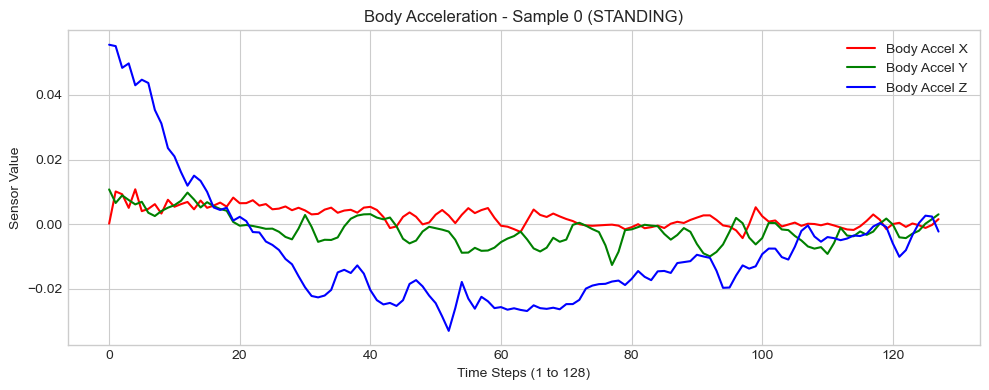

In [5]:
def plot_sample_acceleration(sample_idx):

    sample_data = X_train[sample_idx]
    activity_id = int(y_train[sample_idx][0])
    activity_name = activity_dict[activity_id]

    plt.figure(figsize=(10, 4))


    plt.plot(sample_data[:, 0], label=channel_names[0], color='r')
    plt.plot(sample_data[:, 1], label=channel_names[1], color='g')
    plt.plot(sample_data[:, 2], label=channel_names[2], color='b')

    plt.title(f'Body Acceleration - Sample {sample_idx} ({activity_name})')
    plt.xlabel('Time Steps (1 to 128)')
    plt.ylabel('Sensor Value')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


plot_sample_acceleration(0)

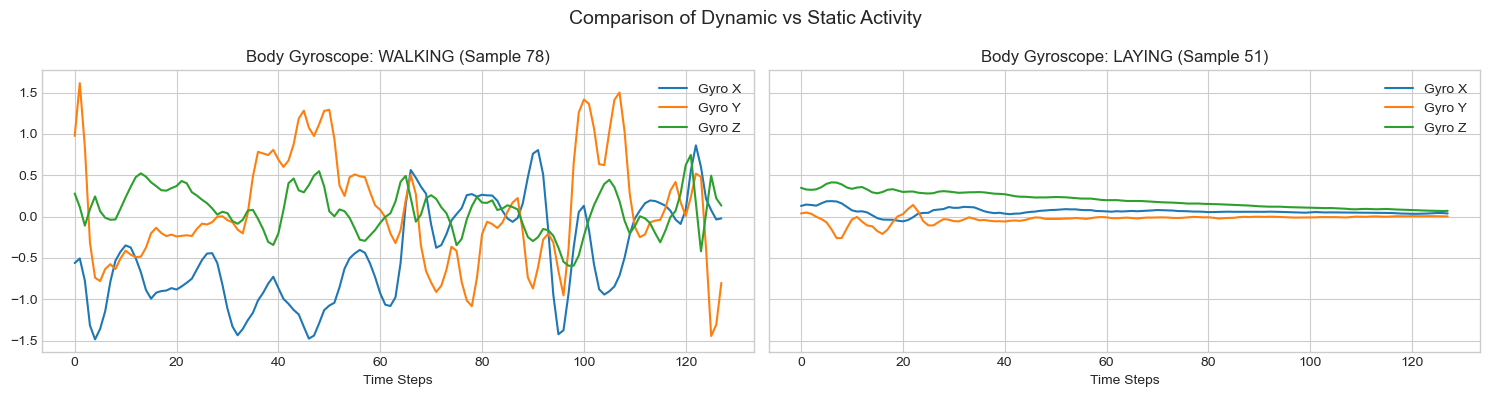

In [6]:
walking_idx = np.where(y_train == 1)[0][0]
laying_idx = np.where(y_train == 6)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)


axes[0].plot(X_train[walking_idx, :, 3], label='Gyro X')
axes[0].plot(X_train[walking_idx, :, 4], label='Gyro Y')
axes[0].plot(X_train[walking_idx, :, 5], label='Gyro Z')
axes[0].set_title(f'Body Gyroscope: WALKING (Sample {walking_idx})')
axes[0].set_xlabel('Time Steps')
axes[0].legend()


axes[1].plot(X_train[laying_idx, :, 3], label='Gyro X')
axes[1].plot(X_train[laying_idx, :, 4], label='Gyro Y')
axes[1].plot(X_train[laying_idx, :, 5], label='Gyro Z')
axes[1].set_title(f'Body Gyroscope: LAYING (Sample {laying_idx})')
axes[1].set_xlabel('Time Steps')
axes[1].legend()

plt.suptitle('Comparison of Dynamic vs Static Activity', fontsize=14)
plt.tight_layout()
plt.show()